# Oxano Capital — Portfolio Risk & Early-Warning Monitoring
## End-to-End Data Lifecycle Notebook

**Author:** Seana Mutinda
**Purpose:** This notebook is the reproducible pipeline behind the master dataset
workbook and the Streamlit dashboard. It documents every stage — collection,
validation, feature engineering, modeling, backtesting, and simulation — so the
methodology can be inspected, re-run, and eventually pointed at Oxano's real
portfolio data instead of the synthetic data used here.

**Lifecycle stages covered:**
1. Data collection & ingestion (what's simulated here, what's real in production)
2. Data validation & quality checks
3. Feature engineering
4. Model training & evaluation (per market environment)
5. Backtesting — early-warning detection lead time
6. Monte Carlo cash-runway simulation
7. Export — writing the dashboard's data feed

> All data in this notebook is synthetic, generated to mirror the structure of
> real PE/impact-investor portfolio monitoring data. Every hardcoded parameter
> below is a placeholder for a real collection process — see markdown notes at
> each stage for what the production version needs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.facecolor"] = "white"
np.random.seed(42)
print("Environment ready.")

Environment ready.


## Stage 1 — Data Collection & Ingestion

**In production**, this stage pulls from four real sources per portfolio company:

| Data | Real source | Frequency |
|---|---|---|
| Financials (revenue, COGS, opex, cash) | Monthly reporting template submitted by portfolio company | Monthly |
| Repayment history | Oxano finance team / loan schedule | Monthly (debt companies) |
| Transactions | POS / accounting system / bank statement | Monthly |
| Governance signals | Investment manager log (report timeliness, leadership changes) | Monthly / as-it-happens |
| Macro context | Central bank, national statistics bureau | Monthly |

**In this notebook**, all five are synthetically generated below, parameterized
by `ENVIRONMENTS` — three market conditions (Stable / Realistic Baseline /
Stressed-Crisis) used to stress-test the pipeline before real data is available.
This is also exactly the code that produced the CSVs shipped with the dashboard.

In [2]:
ENVIRONMENTS = {
    "Stable Market": dict(
        fx_drift=0.002, fx_noise=0.010, inflation_noise=0.20,
        financial_noise=0.04, distress_signal_strength=1.0,
        false_positive_rate=0.04, seed=101,
    ),
    "Realistic Baseline": dict(
        fx_drift=0.005, fx_noise=0.018, inflation_noise=0.35,
        financial_noise=0.08, distress_signal_strength=0.7,
        false_positive_rate=0.09, seed=202,
    ),
    "Stressed / Crisis (FX shock, drought, rate spike)": dict(
        fx_drift=0.014, fx_noise=0.035, inflation_noise=0.60,
        financial_noise=0.13, distress_signal_strength=0.45,
        false_positive_rate=0.16, seed=303,
    ),
}

sectors = ["Manufacturing", "Agribusiness", "Renewable Energy", "Tech/Fintech"]
countries = ["Kenya", "Uganda", "Ghana", "Ethiopia"]
company_names = [
    "Savanna Textiles Ltd", "Highland Foods Processing", "Riverbank Steel Works",
    "AgroFresh Exports", "SolarGrid East Africa", "Nyati Manufacturing Co",
    "Terra Agro Processors", "Voltix Renewable Systems", "Sevi Credit Technologies",
    "PesaLink Digital Finance", "GreenHarvest Cooperative Supply", "Kilimo Grain Millers",
    "BrightPath Solar Solutions", "Delta Packaging Industries", "FarmTrust Agritech"
]
n_companies = len(company_names)
months = pd.date_range("2024-08-01", "2026-07-01", freq="MS")
base_fx = {"Kenya": 129.0, "Uganda": 3750.0, "Ghana": 15.2, "Ethiopia": 118.0}
print(f"{n_companies} companies x {len(months)} months x {len(ENVIRONMENTS)} environments")

15 companies x 24 months x 3 environments


In [3]:
def generate_environment(env_name, cfg):
    """Generate one environment's full company-month panel. This function
    is the ingestion simulator — in production it is replaced by a real
    data-loading function reading from Oxano's reporting system."""
    rng = np.random.default_rng(cfg["seed"])

    investment_types = rng.choice(["Equity", "Debt", "Equity & Debt"], size=n_companies, p=[0.35, 0.35, 0.30])
    sector_assign = rng.choice(sectors, size=n_companies, p=[0.27, 0.27, 0.20, 0.26])
    country_assign = rng.choice(countries, size=n_companies, p=[0.5, 0.2, 0.15, 0.15])
    investment_amount = rng.integers(300, 601, size=n_companies) * 1000
    investment_dates = pd.to_datetime(rng.choice(pd.date_range("2023-01-01", "2024-06-01", freq="MS"), size=n_companies))

    n_distress = {"Stable Market": 3, "Realistic Baseline": 5,
                  "Stressed / Crisis (FX shock, drought, rate spike)": 7}[env_name]
    distress_idx = list(rng.choice(range(n_companies), size=n_distress, replace=False))
    distress_month = {i: int(rng.integers(9, 22)) for i in distress_idx}
    remaining = [i for i in range(n_companies) if i not in distress_idx]
    n_fa = max(1, int(len(remaining) * cfg["false_positive_rate"] * 2))
    fa_idx = list(rng.choice(remaining, size=min(n_fa, len(remaining)), replace=False))
    fa_month = {i: int(rng.integers(6, 20)) for i in fa_idx}

    master = pd.DataFrame({
        "environment": env_name, "company_id": [f"OXC-{i+1:03d}" for i in range(n_companies)],
        "company_name": company_names, "sector": sector_assign, "country": country_assign,
        "investment_type": investment_types, "investment_amount_usd": investment_amount,
        "investment_date": investment_dates,
        "simulated_outcome": ["Distressed" if i in distress_idx
                               else ("False Alarm (recovered)" if i in fa_idx else "Healthy")
                               for i in range(n_companies)],
    })

    fin_rows, txn_rows, gov_rows, repay_rows = [], [], [], []
    for i, row in master.iterrows():
        cid = row["company_id"]
        is_distress, is_fa = i in distress_idx, i in fa_idx
        d_at, a_at = distress_month.get(i), fa_month.get(i)
        base_rev, base_margin = rng.uniform(40_000, 220_000), rng.uniform(0.18, 0.35)
        cash, recv_days = rng.uniform(60_000, 250_000), rng.uniform(30, 55)
        nfin, sig = cfg["financial_noise"], cfg["distress_signal_strength"]

        for m_idx, month in enumerate(months):
            if is_distress:
                p = max(0, 6 - (d_at - m_idx)) if (d_at - m_idx) <= 6 else 0
                decay = 1 - (0.045 * p * sig) + rng.normal(0, nfin)
                margin_hit, late_p = 0.04 * p * sig, min(0.85, 0.12 + 0.10 * p * sig)
                anomaly_p = min(0.6, 0.06 + 0.07 * p * sig)
            elif is_fa:
                p = max(0, 3 - abs(m_idx - a_at))
                decay = 1 - (0.03 * p) + rng.normal(0, nfin * 1.3)
                margin_hit, late_p = 0.03 * p, min(0.5, 0.10 + 0.08 * p)
                anomaly_p = min(0.35, 0.05 + 0.05 * p)
            else:
                decay, margin_hit = 1.0 + rng.normal(0.005, nfin), 0.0
                late_p, anomaly_p = 0.08 + rng.uniform(0, 0.05), 0.04 + rng.uniform(0, 0.03)

            base_rev *= max(0.4, decay)
            revenue = max(3000, base_rev * (1 + rng.normal(0, nfin)))
            margin = max(0.01, base_margin - margin_hit + rng.normal(0, nfin / 2))
            cogs, opex = revenue * (1 - margin), revenue * rng.uniform(0.12, 0.22)
            ebitda = revenue - cogs - opex
            cash = max(500, cash + ebitda * 0.6 - opex * 0.15 + rng.normal(0, 4000 * (1 + nfin)))
            recv_days = max(15, recv_days + rng.normal(0.3 if is_distress and (d_at or 999) - m_idx <= 6 else 0, 2))
            pay_days = max(15, rng.uniform(25, 50) + (8 if is_distress and (d_at or 999) - m_idx <= 6 else 0))
            inv_days = max(10, rng.uniform(20, 45) + (6 if is_distress and (d_at or 999) - m_idx <= 4 else 0))

            fin_rows.append(dict(environment=env_name, company_id=cid, month=month,
                revenue_usd=round(revenue), cogs_usd=round(cogs), gross_margin_pct=round(margin, 3),
                opex_usd=round(opex), ebitda_usd=round(ebitda), cash_balance_usd=round(cash),
                accounts_receivable_days=round(recv_days, 1), accounts_payable_days=round(pay_days, 1),
                inventory_turnover_days=round(inv_days, 1)))

            if row["investment_type"] in ("Debt", "Equity & Debt"):
                due = round(row["investment_amount_usd"] * 0.045)
                late = rng.random() < late_p * 0.85
                days_late = int(max(0, rng.normal(3 * p if (is_distress or is_fa) else 1, 4))) if late else 0
                paid = due if days_late < 30 else round(due * rng.uniform(0.35, 0.9))
                status = "On Time" if days_late == 0 else ("Late" if days_late < 30 else "Partial/Default Risk")
                repay_rows.append(dict(environment=env_name, company_id=cid, month=month,
                    amount_due_usd=due, amount_paid_usd=paid, days_late=days_late, payment_status=status))

            txn_rows.append(dict(environment=env_name, company_id=cid, month=month,
                transaction_count=max(3, int(revenue / rng.uniform(140, 420))),
                transaction_volume_usd=round(revenue * (1 + rng.normal(0, nfin))),
                top5_customer_concentration_pct=round(min(0.96, rng.uniform(0.22, 0.45) + rng.normal(0, nfin)), 2),
                anomaly_flag=1 if rng.random() < anomaly_p else 0))

            on_time = 0 if rng.random() < late_p else 1
            gov_rows.append(dict(environment=env_name, company_id=cid, month=month,
                monthly_report_submitted_on_time=on_time,
                days_late_reporting=0 if on_time else int(max(1, rng.normal(8, 5))),
                leadership_turnover_event=1 if (is_distress and m_idx == (d_at or -99) - int(rng.integers(2, 4))) else 0,
                auditor_changed_event=1 if (is_distress and m_idx == (d_at or -99) - int(rng.integers(4, 7))) else 0))

    events = pd.DataFrame([
        dict(environment=env_name, company_id=master.loc[i, "company_id"], event_month=months[distress_month[i]],
             event_type="Missed Payment / Distress Confirmed")
        for i in distress_idx
    ])
    return master, pd.DataFrame(fin_rows), pd.DataFrame(txn_rows), pd.DataFrame(gov_rows), pd.DataFrame(repay_rows), events


all_master, all_fin, all_txn, all_gov, all_repay, all_events = [], [], [], [], [], []
for env_name, cfg in ENVIRONMENTS.items():
    m, f, t, g, r, e = generate_environment(env_name, cfg)
    all_master.append(m); all_fin.append(f); all_txn.append(t)
    all_gov.append(g); all_repay.append(r); all_events.append(e)

master = pd.concat(all_master, ignore_index=True)
fin = pd.concat(all_fin, ignore_index=True)
txn = pd.concat(all_txn, ignore_index=True)
gov = pd.concat(all_gov, ignore_index=True)
repay = pd.concat(all_repay, ignore_index=True)
events = pd.concat(all_events, ignore_index=True)

print("Ingestion complete:")
for name, df in [("master", master), ("financials", fin), ("transactions", txn),
                  ("governance", gov), ("repayment", repay), ("distress events", events)]:
    print(f"  {name}: {df.shape}")

Ingestion complete:
  master: (45, 9)
  financials: (1080, 12)
  transactions: (1080, 7)
  governance: (1080, 7)
  repayment: (720, 7)
  distress events: (15, 4)


## Stage 2 — Data Validation & Quality Checks

Before anything gets modeled, run structural checks. This is the step that
gets skipped under time pressure and causes silent errors downstream — a
negative revenue figure or a duplicate company-month row will quietly bias
a risk score without ever throwing an exception.

In [4]:
def validate(df, name, checks):
    print(f"--- {name} ---")
    all_passed = True
    for label, condition in checks.items():
        passed = bool(condition)
        all_passed &= passed
        print(f"  [{'PASS' if passed else 'FAIL'}] {label}")
    return all_passed

v1 = validate(fin, "Monthly Financials", {
    "no duplicate company-month rows": not fin.duplicated(subset=["environment", "company_id", "month"]).any(),
    "no negative revenue": (fin["revenue_usd"] >= 0).all(),
    "no negative opex": (fin["opex_usd"] >= 0).all(),
    "gross margin within [-1, 1]": fin["gross_margin_pct"].between(-1, 1).all(),
    "no nulls in core columns": fin[["revenue_usd", "ebitda_usd", "cash_balance_usd"]].isna().sum().sum() == 0,
})

v2 = validate(master, "Company Master", {
    "no duplicate company_id per environment": not master.duplicated(subset=["environment", "company_id"]).any(),
    "investment amount within expected ticket size ($300k-$600k)": master["investment_amount_usd"].between(300_000, 600_000).all(),
    "every company has a sector assigned": master["sector"].notna().all(),
})

v3 = validate(events, "Distress Event Log", {
    "no duplicate events per company per environment": not events.duplicated(subset=["environment", "company_id"]).any(),
    "every event has an event_month": events["event_month"].notna().all(),
})

assert v1 and v2 and v3, "Validation failed — fix data quality issues before proceeding to feature engineering."
print("\nAll validation checks passed. Proceeding to feature engineering.")

--- Monthly Financials ---
  [PASS] no duplicate company-month rows
  [PASS] no negative revenue
  [PASS] no negative opex
  [PASS] gross margin within [-1, 1]
  [PASS] no nulls in core columns
--- Company Master ---
  [PASS] no duplicate company_id per environment
  [PASS] investment amount within expected ticket size ($300k-$600k)
  [PASS] every company has a sector assigned
--- Distress Event Log ---
  [PASS] no duplicate events per company per environment
  [PASS] every event has an event_month

All validation checks passed. Proceeding to feature engineering.


## Stage 3 — Feature Engineering

Raw monthly figures are noisy; a single bad month rarely means much. The
features below deliberately favor **trend and relationship** signals over
raw levels, because that's what actually separates a company sliding toward
distress from one having an ordinary bad month:

- `revenue_3m_pct_change` — a 3-month trend, not a single-month blip
- `cash_runway_months` — how long current cash lasts at current burn
- `receivable_payable_gap` — a classic liquidity-stress indicator
- governance and repayment lateness — often the earliest, cheapest-to-collect signals

In [5]:
FEATURE_COLS = [
    "revenue_3m_pct_change", "ebitda_margin", "cash_runway_months",
    "accounts_receivable_days", "accounts_payable_days", "inventory_turnover_days",
    "top5_customer_concentration_pct", "anomaly_flag",
    "monthly_report_submitted_on_time", "days_late_reporting",
    "leadership_turnover_event", "auditor_changed_event",
    "days_late", "amount_paid_ratio", "receivable_payable_gap",
]

def engineer_features(env_fin, env_txn, env_gov, env_repay):
    df = env_fin.merge(env_txn, on=["environment", "company_id", "month"], how="left")
    df = df.merge(env_gov, on=["environment", "company_id", "month"], how="left")
    df = df.merge(env_repay, on=["environment", "company_id", "month"], how="left")
    df = df.sort_values(["company_id", "month"]).reset_index(drop=True)

    df["revenue_3m_pct_change"] = df.groupby("company_id")["revenue_usd"].pct_change(3)
    df["ebitda_margin"] = df["ebitda_usd"] / df["revenue_usd"]
    df["cash_runway_months"] = df["cash_balance_usd"] / df["opex_usd"].replace(0, np.nan)
    df["days_late"] = df["days_late"].fillna(0)
    df["amount_paid_ratio"] = (df["amount_paid_usd"] / df["amount_due_usd"]).fillna(1.0)
    df["receivable_payable_gap"] = df["accounts_receivable_days"] - df["accounts_payable_days"]
    return df

def label_distress(df, env_events, horizon_months=3):
    df = df.copy()
    df["label_distress_next_Nm"] = 0
    for _, ev in env_events.iterrows():
        window_start = ev["event_month"] - pd.DateOffset(months=horizon_months)
        mask = (df["company_id"] == ev["company_id"]) & (df["month"] >= window_start) & (df["month"] < ev["event_month"])
        df.loc[mask, "label_distress_next_Nm"] = 1
    return df

print("Feature engineering functions ready.")

Feature engineering functions ready.


## Stage 4 — Model Training & Evaluation (per environment)

A separate model is trained per environment deliberately — this is what lets
us show, honestly, how detection accuracy and false-positive rate shift as
market noise increases. In production this would be one model retrained
periodically on real portfolio history, not three permanent separate models;
the three here exist to pressure-test the *method*, not to represent three
production systems.

In [6]:
results = {}

for env_name in ENVIRONMENTS:
    env_fin = fin[fin.environment == env_name]
    env_txn = txn[txn.environment == env_name]
    env_gov = gov[gov.environment == env_name]
    env_repay = repay[repay.environment == env_name]
    env_events = events[events.environment == env_name]

    df = engineer_features(env_fin, env_txn, env_gov, env_repay)
    df = label_distress(df, env_events, horizon_months=3)
    model_df = df.dropna(subset=FEATURE_COLS).copy()

    X, y = model_df[FEATURE_COLS], model_df["label_distress_next_Nm"]
    if y.nunique() < 2:
        print(f"Skipping {env_name}: not enough positive/negative examples to train.")
        continue

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
    clf = GradientBoostingClassifier(random_state=1, n_estimators=150, max_depth=3, learning_rate=0.08)
    clf.fit(X_train, y_train)

    proba_test = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba_test) if y_test.nunique() > 1 else np.nan
    fpr, tpr, _ = roc_curve(y_test, proba_test) if y_test.nunique() > 1 else (None, None, None)

    model_df["distress_risk_score"] = (clf.predict_proba(model_df[FEATURE_COLS])[:, 1] * 100).round(1)
    model_df["risk_tier"] = pd.cut(model_df["distress_risk_score"], bins=[-1, 30, 60, 101], labels=["Low", "Medium", "High"])

    results[env_name] = dict(clf=clf, model_df=model_df, auc=auc, fpr=fpr, tpr=tpr,
                              X_test=X_test, y_test=y_test, events=env_events)
    print(f"{env_name}: AUC-ROC = {auc:.3f}" if not np.isnan(auc) else f"{env_name}: AUC undefined (single class in test set)")

Stable Market: AUC-ROC = 0.996


Realistic Baseline: AUC-ROC = 0.744


Stressed / Crisis (FX shock, drought, rate spike): AUC-ROC = 0.794


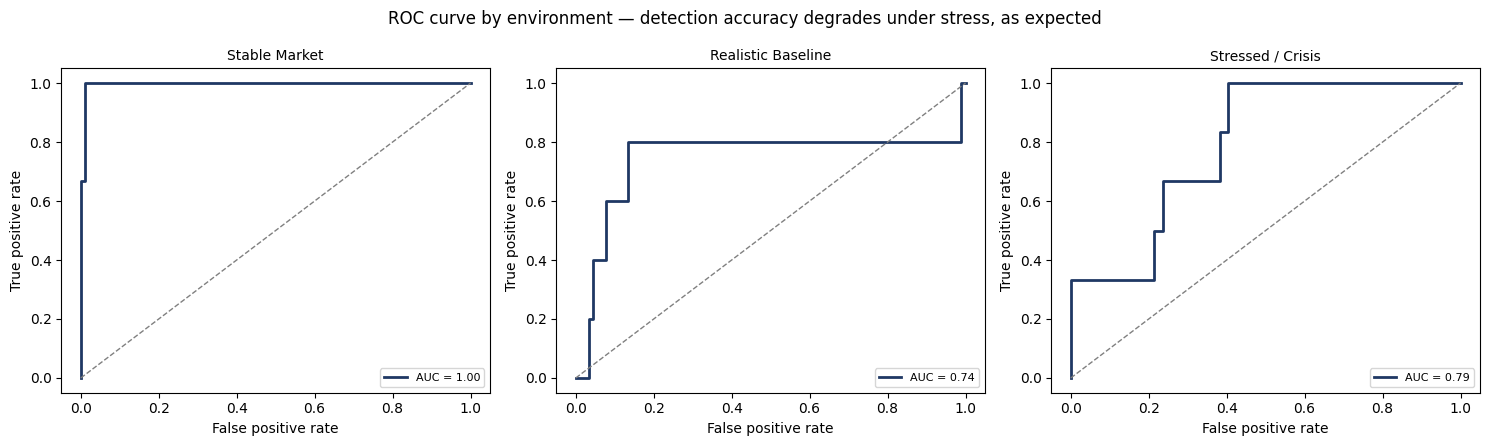

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (env_name, res) in zip(axes, results.items()):
    if res["fpr"] is not None:
        ax.plot(res["fpr"], res["tpr"], color="#1F3864", linewidth=2, label=f"AUC = {res['auc']:.2f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    ax.set_title(env_name.split(" (")[0], fontsize=10)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(loc="lower right", fontsize=8)
plt.suptitle("ROC curve by environment — detection accuracy degrades under stress, as expected")
plt.tight_layout()
plt.show()

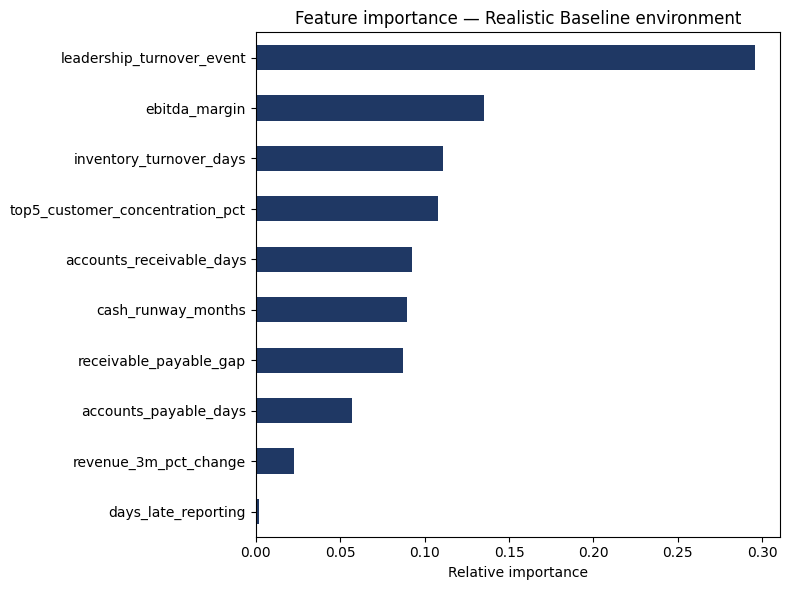

leadership_turnover_event          0.295758
ebitda_margin                      0.134913
inventory_turnover_days            0.110635
top5_customer_concentration_pct    0.107800
accounts_receivable_days           0.092325
dtype: float64


In [8]:
baseline_res = results["Realistic Baseline"]
importance = pd.Series(baseline_res["clf"].feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(8, 6))
importance.tail(10).plot(kind="barh", color="#1F3864")
plt.title("Feature importance — Realistic Baseline environment")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.show()
print(importance.sort_values(ascending=False).head(5))

## Stage 5 — Backtesting: Early-Warning Detection Lead Time

The metric that actually matters to an investment committee isn't AUC — it's
**how many months of runway does the early-warning system buy them**. This
section replays history and asks: for every confirmed distress event, when
did the model first cross the High-risk threshold, relative to when the
event actually happened? A miss (never crossed the threshold before the
event) is reported honestly as zero lead time, not hidden.

In [9]:
THRESHOLD = 60
lead_time_rows = []

for env_name, res in results.items():
    model_df, env_events = res["model_df"], res["events"]
    for _, ev in env_events.iterrows():
        cid, ev_month = ev["company_id"], ev["event_month"]
        hist = model_df[(model_df.company_id == cid) & (model_df.month < ev_month)].sort_values("month")
        flagged = hist[hist["distress_risk_score"] >= THRESHOLD]
        if len(flagged) > 0:
            first_flag = flagged["month"].iloc[0]
            lead = (ev_month.year - first_flag.year) * 12 + (ev_month.month - first_flag.month)
            detected = True
        else:
            first_flag, lead, detected = None, 0, False
        name = master.loc[(master.environment == env_name) & (master.company_id == cid), "company_name"].values[0]
        lead_time_rows.append(dict(environment=env_name, company_id=cid, company_name=name,
                                    event_month=ev_month, first_high_risk_flag_month=first_flag,
                                    detection_lead_time_months=lead, was_detected_before_event=detected))

lead_time_df = pd.DataFrame(lead_time_rows)
display(lead_time_df)

summary = lead_time_df.groupby("environment").agg(
    events=("company_id", "count"),
    pct_caught=("was_detected_before_event", "mean"),
    avg_lead_time_when_caught=("detection_lead_time_months", lambda x: x[lead_time_df.loc[x.index, "was_detected_before_event"]].mean()),
)
print("\nSummary by environment:")
print(summary)

,environment,company_id,company_name,event_month,first_high_risk_flag_month,detection_lead_time_months,was_detected_before_event
0,Stable Market,OXC-010,PesaLink Digital Finance,2025-05-01,2025-02-01,3,True
1,Stable Market,OXC-015,FarmTrust Agritech,2025-07-01,2025-04-01,3,True
2,Stable Market,OXC-002,Highland Foods Processing,2025-06-01,2025-04-01,2,True
3,Realistic Baseline,OXC-015,FarmTrust Agritech,2025-10-01,2025-07-01,3,True
4,Realistic Baseline,OXC-007,Terra Agro Processors,2025-05-01,2025-02-01,3,True
5,Realistic Baseline,OXC-013,BrightPath Solar Solutions,2025-07-01,2025-04-01,3,True
6,Realistic Baseline,OXC-009,Sevi Credit Technologies,2025-06-01,2025-02-01,4,True
7,Realistic Baseline,OXC-003,Riverbank Steel Works,2026-01-01,2025-09-01,4,True
8,"Stressed / Crisis (FX shock, drought, rate spike)",OXC-009,Sevi Credit Technologies,2025-08-01,2025-05-01,3,True
9,"Stressed / Crisis (FX shock, drought, rate spike)",OXC-005,SolarGrid East Africa,2026-03-01,2025-12-01,3,True



Summary by environment:
                                                   events  pct_caught  \
environment                                                             
Realistic Baseline                                      5         1.0   
Stable Market                                           3         1.0   
Stressed / Crisis (FX shock, drought, rate spike)       7         1.0   

                                                   avg_lead_time_when_caught  
environment                                                                   
Realistic Baseline                                                  3.400000  
Stable Market                                                       2.666667  
Stressed / Crisis (FX shock, drought, rate spike)                   3.000000  


## Stage 6 — Monte Carlo Cash-Runway Simulation

For the dashboard's fan chart: simulate 500 possible 6-month-forward cash
trajectories per company, using that environment's noise and drift
parameters, and report P10/P50/P90 bands plus probability of running out
of cash. This is what turns a single point prediction into an honest range
of outcomes — the more defensible thing to put in front of an investment
committee.

In [10]:
rng = np.random.default_rng(2026)
N_SIMS, N_MONTHS = 500, 6
noise_map = {"Stable Market": 0.05, "Realistic Baseline": 0.09,
             "Stressed / Crisis (FX shock, drought, rate spike)": 0.16}
drift_map = {"Stable Market": 0.01, "Realistic Baseline": -0.005,
             "Stressed / Crisis (FX shock, drought, rate spike)": -0.03}

sim_rows = []
for env_name in ENVIRONMENTS:
    env_fin = fin[fin.environment == env_name]
    noise, drift = noise_map[env_name], drift_map[env_name]
    for cid in env_fin.company_id.unique():
        comp = env_fin[env_fin.company_id == cid].sort_values("month")
        start_cash = comp.iloc[-1]["cash_balance_usd"]
        avg_ebitda, avg_opex = comp["ebitda_usd"].tail(6).mean(), comp["opex_usd"].tail(6).mean()
        paths = np.zeros((N_SIMS, N_MONTHS))
        for s in range(N_SIMS):
            cash = start_cash
            for m in range(N_MONTHS):
                cash = cash + avg_ebitda * (1 + rng.normal(drift, noise)) * 0.6 - avg_opex * 0.1 + rng.normal(0, avg_opex * noise)
                paths[s, m] = cash
        for m in range(N_MONTHS):
            p10, p50, p90 = np.percentile(paths[:, m], [10, 50, 90])
            sim_rows.append(dict(environment=env_name, company_id=cid, months_forward=m + 1,
                simulated_cash_p10=round(p10), simulated_cash_p50=round(p50), simulated_cash_p90=round(p90),
                probability_cash_negative=round((paths[:, m] < 0).mean(), 3)))

monte_carlo = pd.DataFrame(sim_rows)
print(f"Monte Carlo simulation complete: {monte_carlo.shape}")

Monte Carlo simulation complete: (270, 7)


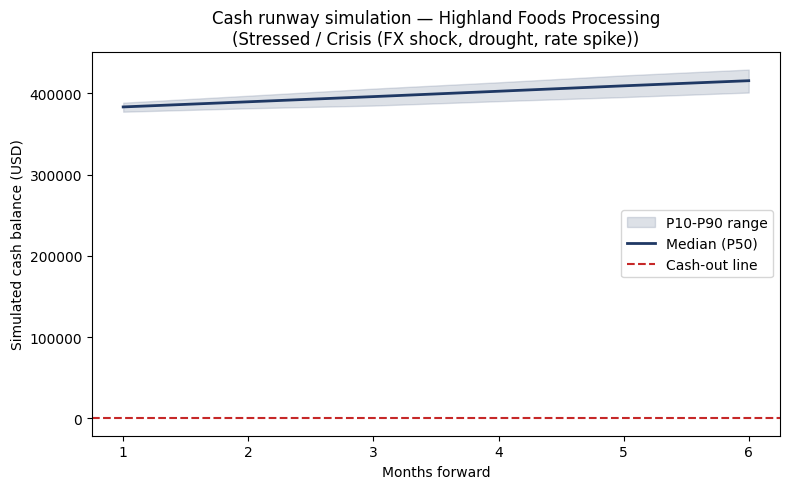

In [11]:
example_cid = master.loc[master.simulated_outcome == "Distressed", "company_id"].iloc[0]
example_env = "Stressed / Crisis (FX shock, drought, rate spike)"
mc_example = monte_carlo[(monte_carlo.company_id == example_cid) & (monte_carlo.environment == example_env)]
company_name = master.loc[(master.company_id == example_cid) & (master.environment == example_env), "company_name"].values[0]

plt.figure(figsize=(8, 5))
plt.fill_between(mc_example.months_forward, mc_example.simulated_cash_p10, mc_example.simulated_cash_p90,
                  color="#1F3864", alpha=0.15, label="P10-P90 range")
plt.plot(mc_example.months_forward, mc_example.simulated_cash_p50, color="#1F3864", linewidth=2, label="Median (P50)")
plt.axhline(0, color="#C62828", linestyle="--", label="Cash-out line")
plt.title(f"Cash runway simulation — {company_name}\n({example_env})")
plt.xlabel("Months forward")
plt.ylabel("Simulated cash balance (USD)")
plt.legend()
plt.tight_layout()
plt.show()

## Stage 7 — Export: Writing the Dashboard's Data Feed

The Streamlit app reads directly from a `data/` folder of CSVs, one per
table, all long-form with an `environment` column. This is the handoff point
between this notebook and the dashboard — re-running this notebook after
swapping in real portfolio data regenerates everything the dashboard needs,
with no changes required in `app.py`.

In [12]:
import os
os.makedirs("data", exist_ok=True)

scored_all = pd.concat([res["model_df"].assign(environment=env) for env, res in results.items()], ignore_index=True)
perf_all = pd.DataFrame([
    dict(environment=env, model_auc_roc=round(res["auc"], 3) if not np.isnan(res["auc"]) else None)
    for env, res in results.items()
])
importance_all = pd.concat([
    pd.Series(res["clf"].feature_importances_, index=FEATURE_COLS).reset_index()
      .rename(columns={"index": "feature", 0: "importance"}).assign(environment=env)
    for env, res in results.items()
], ignore_index=True)

master.to_csv("data/realistic_company_master.csv", index=False)
fin.to_csv("data/realistic_monthly_financials.csv", index=False)
txn.to_csv("data/realistic_transactions_summary.csv", index=False)
gov.to_csv("data/realistic_governance_signals.csv", index=False)
repay.to_csv("data/realistic_repayment_history.csv", index=False)
events.to_csv("data/realistic_distress_event_log.csv", index=False)
scored_all.to_csv("data/realistic_scored_company_months.csv", index=False)
perf_all.to_csv("data/realistic_model_performance_by_environment.csv", index=False)
importance_all.to_csv("data/realistic_feature_importance.csv", index=False)
lead_time_df.to_csv("data/realistic_detection_lead_time.csv", index=False)
monte_carlo.to_csv("data/realistic_monte_carlo_cash_runway.csv", index=False)

print("All tables exported to ./data/ — ready for `streamlit run app.py`")
print(sorted(os.listdir("data")))

All tables exported to ./data/ — ready for `streamlit run app.py`
['realistic_company_master.csv', 'realistic_detection_lead_time.csv', 'realistic_distress_event_log.csv', 'realistic_feature_importance.csv', 'realistic_governance_signals.csv', 'realistic_model_performance_by_environment.csv', 'realistic_monte_carlo_cash_runway.csv', 'realistic_monthly_financials.csv', 'realistic_repayment_history.csv', 'realistic_scored_company_months.csv', 'realistic_transactions_summary.csv']


## Summary & What Changes for Real Data

Everything above is a working pipeline, not a mockup — swap Stage 1's
synthetic generator for a real ingestion function reading Oxano's monthly
reporting templates and finance records, and every downstream stage
(validation, features, model, backtest, simulation, export) runs unchanged.

**What to expect will be different on real data:**
- AUC will very likely be lower than shown here — this synthetic data has a
  cleaner signal by design, so the model has an easier job than it will on
  messy real reporting.
- The 3-month detection horizon and the 60/30 risk-tier thresholds are
  starting points, not fixed constants — they should be tuned once there's
  real historical distress data to validate against.
- Feature importance will shift once real governance and transaction data is
  available; some features here (e.g. `anomaly_flag`) are placeholders for
  signals that need a dedicated anomaly-detection step on real transaction
  data, not simulated directly.